# MetaLore Default Environment Demo


This notebook demonstrates the basic usage of the MetaLore smart city simulator.

In [1]:
import sys
sys.path.insert(0, '.')

from metalore.scenarios import SingleCellEnv, MultiCellEnv
from metalore.config import default_config, small_config, large_config, multi_cell_config

print("MetaLore imported successfully!")

MetaLore imported successfully!


In [2]:
envs = {
    #'default': SingleCellEnv(config=default_config()),
    #'small': SingleCellEnv(config=small_config()),
    #'large': SingleCellEnv(config=large_config()),
    #'multi_cell': MultiCellEnv(config=multi_cell_config()),
}

print(f"{'Environment':<12} {'BSs':<5} {'UEs':<5} {'Sensors':<8} {'BS Positions'}")
print("-" * 80)

for name, env in envs.items():
    env.reset()
    bs_positions = [(bs.x, bs.y) for bs in env.stations.values()]
    print(f"{name:<12} {env.num_bs:<5} {env.num_ues:<5} {env.num_sensors:<8} {bs_positions}")
    
    # Print UE positions
    print(f"  UE Positions: {[ue.position for ue in env.users.values()]}")
    
    # Print Sensor positions
    print(f"  Sensor Positions: {[sensor.position for sensor in env.sensors.values()]}")
    print()

Environment  BSs   UEs   Sensors  BS Positions
--------------------------------------------------------------------------------


--------------------------------------------------
Total steps: 10
Total reward: 10.00


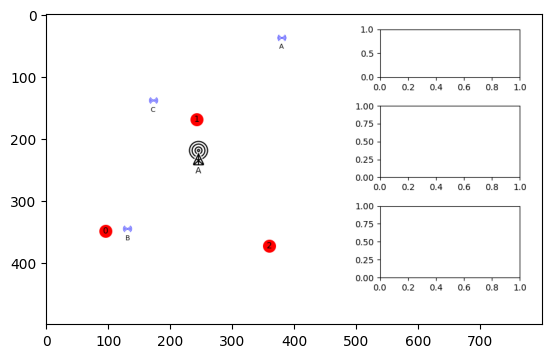

In [3]:
from IPython import display
import matplotlib.pyplot as plt

env = SingleCellEnv(config=default_config())
obs, info = env.reset()

print(f"Environment: {env.num_bs} BS, {env.num_ues} UEs, {env.num_sensors} Sensors")
print(f"Max steps: {env.EP_MAX_TIME}")
print(f"Action space: {env.action_space}")
print("\nRunning 100 timesteps...")
print("-" * 50)

rewards = []
actions_taken = []

for step in range(10):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)
    actions_taken.append(action.copy())

    if terminated or truncated:
        print(f"\nEpisode ended at step {step+1}")
        break


    # render the environment
    plt.imshow(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)

print("-" * 50)
print(f"Total steps: {len(rewards)}")
print(f"Total reward: {sum(rewards):.2f}")

In [4]:
print(env.get_env_config())

AttributeError: 'SingleCellEnv' object has no attribute 'get_env_config'

In [ ]:
import pandas as pd

metrics = env.logger.get_metrics_history()
df = pd.DataFrame(metrics)
df[['timestep', 'reward', 'avg_ue_datarate', 'avg_sensor_datarate', 'num_connections_ue']]


,timestep,reward,avg_ue_datarate,avg_sensor_datarate,num_connections_ue
0,0,1.0,161.325203,162.929524,3
1,1,1.0,293.495128,42.350239,3
2,2,1.0,10.875869,314.698969,3
3,3,1.0,264.148408,79.294889,3
4,4,1.0,192.122549,154.102684,3
5,5,1.0,341.199758,14.117068,3
6,6,1.0,25.643720,331.728740,3
7,7,1.0,154.738574,210.972098,3
8,8,1.0,196.773153,175.891702,3
9,9,1.0,200.735864,179.417605,3
